# Replay the Log

## At-least-once delivery, idempotent sinks, and a replay you can diff

**Standalone notebook.** It generates its own wallet event stream, runs a log with
Kafka semantics in memory, and compares five ways of writing consumed events into a
database. It defines every function it uses, imports nothing from the project
package, and writes nothing to disk. The definitions are copied from the repo
source by the notebook builder, so they cannot drift from `run.py`.

### What you will measure

A wallet service writes about 50,000 events to a log with 3 partitions. The log
contains three planted faults.

1. The producer retried 1,000 events, so the same `event_id` sits at two offsets.
2. 400 profile updates arrive after a newer update for the same account.
3. The consumer is killed 52 times, at positions that are the same for every strategy.

Every strategy sees the same stream and the same crashes. The answer key says what
each balance and profile should be, so each strategy gets a score and not an opinion.

### Before you run

```
%pip install -q duckdb
```

Colab and Kaggle already have matplotlib. The full notebook takes about 3 minutes
because each of the strategies makes a pass over 51,000 records in transactions.
It has 6 charts.

### Contents

| # | Section | What you get |
|---|---|---|
| 1 | [Stream and answer key](#s1) | a log with known faults at exact counts |
| 2 | [The log and the consumer](#s2) | partitions, offsets, commit, seek |
| 3 | [The sinks](#s3) | naive, commit first, dedup, atomic |
| 4 | [The scoreboard](#s4) | accounts wrong, money drift, lost and doubled events |
| 5 | [Profile policies](#s5) | last arrived wins against a guarded upsert |
| 6 | [One account](#s6) | a duplicate, a crash and an out-of-order update, followed through |
| 7 | [The replay proof](#s7) | rewind to zero and diff the sink |
| 8 | [Batch size](#s8) | redelivery grows, correctness does not |
| 9 | [What this does and does not show](#s9) | the honest limits |

Every code cell opens with a header saying what it consumes and what it leaves
behind, so you can start reading at any section.

In [1]:
%pip install -q duckdb

Note: you may need to restart the kernel to use updated packages.


C:\projects\aiml-companion\projects\data-engineering\event-log-replay\.venv\Scripts\python.exe: No module named pip


In [2]:
# ============================================================================
# 0.1  Imports and global settings
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : the standard library, DuckDB and matplotlib namespaces
# Note : Every number in this notebook comes from the seed in CFG, so a
#        rerun prints the same figures.
# ============================================================================
import hashlib
import json
import random
import re
import zlib
from dataclasses import asdict, dataclass, field
from typing import Protocol

import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt

print("duckdb", duckdb.__version__)

duckdb 1.5.6


In [3]:
# ============================================================================
# 0.2  Chart styling
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : the colour palette and the style() helper
# Note : One palette for every chart. Orange marks the failures, blue the
#        baseline, green the fix.
# ============================================================================
# Orange marks failures, blue is the baseline, green is the fix.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#b8b7b2"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 12,
    "axes.titleweight": "600", "axes.titlelocation": "left", "axes.titlepad": 12,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "axes.labelsize": 10,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.8, "legend.frameon": False,
    "legend.fontsize": 9, "lines.linewidth": 2, "lines.markersize": 7,
    "figure.dpi": 110, "font.size": 10,
})


def style(ax, title=None, sub=None, xlabel=None, ylabel=None, grid="x"):
    if title:
        ax.set_title(title, pad=22 if sub else 12)
    if sub:
        ax.text(0, 1.04, sub, transform=ax.transAxes, fontsize=9.5, color=INK2, va="bottom")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    if grid:
        ax.grid(axis=grid, alpha=0.9, zorder=0)
        ax.set_axisbelow(True)
    return ax

<a id="s1"></a>
## 1. The stream and the answer key

The generator builds every event in event-time order first and applies the delivery
faults afterwards. So a fault is always a statement about arrival, and the truth never
changes. Two kinds of event matter.

- **Delta events** are wallet deposits and withdrawals. Applying `+500` twice is wrong
  however the row is keyed.
- **State events** are profile updates carrying absolute values. An upsert can make
  these idempotent, if it knows which update is newest.

In [4]:
# ============================================================================
# 1.1  Configuration, the stream generator, and the answer key
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : CFG, generate(), Stream, partition_for(), Record
# Note : These definitions are copied from the repo by the notebook builder.
#        generate() writes the truth into stream.answer_key. Only
#        score_sink() and the charts are allowed to read it.
# ============================================================================
CFG = {'seed': 20261006,
 'stream': {'topic': 'wallet_events',
            'n_partitions': 3,
            'n_accounts': 2000,
            'n_wallet_events': 45000,
            'n_profile_events': 5000,
            'first_event_time': 1760000000,
            'retry_rate': 0.02,
            'retry_max_gap': 30,
            'late_profile_rate': 0.08,
            'late_max_gap': 50,
            'tie_accounts': 40},
 'crashes': {'every': 997, 'jitter': 0.1},
 'consumer': {'group': 'wallet-sink', 'batch_size': 100},
 'experiments': {'batch_sizes': [50, 100, 500, 5000]},
 'kafka': {'bootstrap_env': 'KAFKA_BOOTSTRAP'}}


@dataclass(frozen=True, slots=True)
class Record:
    partition: int
    offset: int
    key: str
    value: dict


def partition_for(key: str, n_partitions: int) -> int:
    """Stable key -> partition. Python's built-in hash() is salted per process,
    so the same key would land on a different partition on every run and the
    log would not be reproducible. crc32 is the same on every OS."""
    return zlib.crc32(key.encode("utf-8")) % n_partitions


TIERS = ["free", "plus", "pro", "business"]


@dataclass
class Stream:
    """What the producer appends, in arrival order, plus the truth about it."""
    records: list[dict] = field(default_factory=list)
    answer_key: dict = field(default_factory=dict)
    featured: dict = field(default_factory=dict)


def _event_id(kind: str, n: int) -> str:
    return f"{kind}-{n:06d}"


def _build_events(cfg: dict, rng: random.Random) -> tuple[list[dict], dict[int, list[dict]]]:
    s = cfg["stream"]
    slots = ["w"] * s["n_wallet_events"] + ["p"] * s["n_profile_events"]
    rng.shuffle(slots)

    events: list[dict] = []
    updates: dict[int, list[dict]] = {}
    version: dict[int, int] = {}
    t = s["first_event_time"]
    for pos, slot in enumerate(slots):
        t += rng.randint(1, 3)
        account = rng.randrange(s["n_accounts"])
        if slot == "w":
            deposit = rng.random() < 0.6
            ev = {
                "type": "wallet_txn", "event_id": _event_id("w", pos), "account_id": account,
                "kind": "deposit" if deposit else "withdrawal",
                "amount_cents": rng.randint(500, 50_000) if deposit else rng.randint(100, 30_000),
                "event_time": t, "producer_attempt": 0,
            }
        else:
            version[account] = version.get(account, 0) + 1
            ev = {
                "type": "profile_updated", "event_id": _event_id("p", pos), "account_id": account,
                "tier": rng.choice(TIERS),
                "daily_limit_cents": rng.randint(1, 1_000_000) * 100,
                "event_time": t, "version": version[account], "producer_attempt": 0,
            }
            updates.setdefault(account, []).append(ev)
        ev["_pos"] = pos
        events.append(ev)
    # A stale update must never equal the truth by accident, or "wrong" would be
    # unmeasurable. Limits are drawn from 1M values, so collisions are checked, not assumed away.
    for evs in updates.values():
        assert len({e["daily_limit_cents"] for e in evs}) == len(evs), "limit collision"
    return events, updates


def _plant_ties(cfg: dict, rng: random.Random, updates: dict[int, list[dict]]) -> list[int]:
    eligible = sorted(a for a, u in updates.items() if len(u) >= 2)
    chosen = sorted(rng.sample(eligible, cfg["stream"]["tie_accounts"]))
    for a in chosen:
        updates[a][-1]["event_time"] = updates[a][-2]["event_time"]
    return chosen


def _plant_late(cfg: dict, rng: random.Random, updates: dict[int, list[dict]],
                key: dict[str, float]) -> list[str]:
    """Move non-final updates so they arrive after the account's newest update."""
    s = cfg["stream"]
    candidates = sorted((e["event_id"], a) for a, u in updates.items() for e in u[:-1])
    n_late = round(s["late_profile_rate"] * s["n_profile_events"])
    picked = sorted(rng.sample(candidates, n_late))
    for event_id, account in picked:
        newest = updates[account][-1]
        key[event_id] = (key[newest["event_id"]] + rng.randint(1, s["late_max_gap"])
                         + rng.random() * 0.5)
    return [event_id for event_id, _ in picked]


def _plant_retries(cfg: dict, rng: random.Random, events: list[dict],
                   key: dict[str, float]) -> tuple[list[dict], dict[int, float], list[str]]:
    """Each retried event is appended again a few records later in the same partition."""
    s = cfg["stream"]
    n_retry = round(s["retry_rate"] * len(events))
    picked = sorted(rng.sample([e["event_id"] for e in events], n_retry))
    by_id = {e["event_id"]: e for e in events}
    dupes, dupe_key = [], {}
    for event_id in picked:
        copy = dict(by_id[event_id])
        copy["producer_attempt"] = 1
        dupes.append(copy)
        dupe_key[id(copy)] = (key[event_id] + rng.randint(1, s["retry_max_gap"])
                              + rng.random() * 0.5)
    return dupes, dupe_key, picked


def _truth(events: list[dict], updates: dict[int, list[dict]], n_accounts: int) -> dict:
    """Each event_id applied once; the profile is the newest by (event_time, version)."""
    balances = {a: 0 for a in range(n_accounts)}
    for e in events:
        if e["type"] == "wallet_txn":
            sign = 1 if e["kind"] == "deposit" else -1
            balances[e["account_id"]] += sign * e["amount_cents"]
    profiles = {}
    for a, evs in updates.items():
        best = max(evs, key=lambda e: (e["event_time"], e["version"]))
        profiles[str(a)] = {"tier": best["tier"], "daily_limit_cents": best["daily_limit_cents"]}
    return {"balances": {str(a): v for a, v in sorted(balances.items())}, "profiles": profiles}


def _out_of_order_count(arrival: list[dict]) -> int:
    """Profile updates (first copy only) that reached the log after a higher version."""
    newest: dict[int, int] = {}
    seen: set[str] = set()
    late = 0
    for e in arrival:
        if e["type"] != "profile_updated" or e["event_id"] in seen:
            continue
        seen.add(e["event_id"])
        a = e["account_id"]
        if e["version"] < newest.get(a, 0):
            late += 1
        newest[a] = max(newest.get(a, 0), e["version"])
    return late


def _pick_featured(arrival: list[dict], n_partitions: int, retried: set[str], late: set[str]) -> dict:
    """The smallest account that shows all three faults, so its trace fits on a screen.

    It must have a retried wallet event (a duplicate), a late profile update
    (out of order), and one un-retried wallet event to pin a consumer crash on.
    """
    per_acct: dict[int, list[dict]] = {}
    for e in arrival:
        per_acct.setdefault(e["account_id"], []).append(e)
    best = None
    for a in sorted(per_acct):
        evs = per_acct[a]
        has_retry = any(e["type"] == "wallet_txn" and e["event_id"] in retried for e in evs)
        has_late = any(e["event_id"] in late for e in evs)
        targets = [e for e in evs if e["type"] == "wallet_txn" and e["event_id"] not in retried]
        if has_retry and has_late and targets:
            if best is None or len(evs) < best[0]:
                best = (len(evs), a, targets[0]["event_id"])
    if best is None:
        raise RuntimeError("no account shows all three faults; raise the fault rates")
    _, account, crash_event = best
    part = partition_for(str(account), n_partitions)
    offset = -1
    for e in arrival:
        if partition_for(str(e["account_id"]), n_partitions) == part:
            offset += 1
            if e["event_id"] == crash_event and e["producer_attempt"] == 0:
                break
    return {"account_id": account, "partition": part, "crash_offset": offset,
            "crash_event_id": crash_event}


def generate(cfg: dict) -> Stream:
    rng = random.Random(cfg["seed"])
    s = cfg["stream"]
    events, updates = _build_events(cfg, rng)
    tie_accounts = _plant_ties(cfg, rng, updates)
    key = {e["event_id"]: float(e["_pos"]) for e in events}
    late_ids = _plant_late(cfg, rng, updates, key)
    dupes, dupe_key, retried_ids = _plant_retries(cfg, rng, events, key)

    placed = [(key[e["event_id"]], i, e) for i, e in enumerate(events)]
    placed += [(dupe_key[id(d)], len(events) + j, d) for j, d in enumerate(dupes)]
    placed.sort(key=lambda x: (x[0], x[1]))
    ordered = [{k: v for k, v in e.items() if k != "_pos"} for _, _, e in placed]

    truth = _truth(events, updates, s["n_accounts"])
    featured = _pick_featured(ordered, s["n_partitions"], set(retried_ids), set(late_ids))
    truth["wallet_event_ids"] = sorted(e["event_id"] for e in events if e["type"] == "wallet_txn")
    truth["planted"] = {
        "distinct_events": len(events),
        "wallet_events": s["n_wallet_events"],
        "profile_events": s["n_profile_events"],
        "log_records": len(ordered),
        "retried_events": len(retried_ids),
        "retried_wallet_events": sum(1 for i in retried_ids if i.startswith("w-")),
        "retried_profile_events": sum(1 for i in retried_ids if i.startswith("p-")),
        "retried_event_ids": retried_ids,
        "late_profile_updates": len(late_ids),
        "out_of_order_arrivals": _out_of_order_count(ordered),
        "tie_accounts": len(tie_accounts),
        "accounts_with_profile": len(updates),
    }
    return Stream(records=ordered, answer_key=truth, featured=featured)

In [5]:
# ============================================================================
# 1.2  Generate the stream and show what was planted
# ----------------------------------------------------------------------------
# In   : CFG, generate()
# Out  : stream, ANSWER_KEY, the planted-fault table
# Note : Every count here is exact because each fault is placed at a
#        configured rate.
# ============================================================================
stream = generate(CFG)
ANSWER_KEY = stream.answer_key   # read only by score_sink() and the charts
facts = {k: v for k, v in ANSWER_KEY["planted"].items() if k != "retried_event_ids"}
for k, v in facts.items():
    print(f"{k:24s} {v:>8,}")

distinct_events            50,000
wallet_events              45,000
profile_events              5,000
log_records                51,000
retried_events              1,000
retried_wallet_events         891
retried_profile_events        109
late_profile_updates          400
out_of_order_arrivals         400
tie_accounts                   40
accounts_with_profile       1,831


<a id="s2"></a>
## 2. The log and the consumer

`MemoryLog` has the same methods as the file log in the repo. The consumer is copied
unchanged. Its `poll` moves an in-memory position, and only `commit` makes that
position survive a restart. That distinction is what every sink below leans on.

In [6]:
# ============================================================================
# 2.1  An in-memory log with Kafka semantics, and the consumer
# ----------------------------------------------------------------------------
# In   : stream, partition_for()
# Out  : MemoryLog, Consumer, log, MANIFEST, crash_schedule()
# Note : MemoryLog has the same methods as the repo's file-backed log.
#        Consumer is copied unchanged. Nothing is written to disk.
# ============================================================================
class LogBackend(Protocol):
    n_partitions: int

    def append(self, partition: int, key: str, value: dict) -> int: ...
    def end_offset(self, partition: int) -> int: ...
    def read(self, partition: int, offset: int, n: int) -> list[Record]: ...
    def committed(self, group: str) -> dict[int, int]: ...
    def commit(self, group: str, offsets: dict[int, int]) -> None: ...
    def reset_group(self, group: str) -> None: ...


class Consumer:
    """One consumer process. Crashing means throwing this object away."""

    def __init__(self, log: LogBackend, group: str):
        self.log = log
        self.group = group
        committed = log.committed(group)
        self.position = {p: committed.get(p, 0) for p in range(log.n_partitions)}

    def seek(self, partition: int, offset: int) -> None:
        self.position[partition] = offset

    def poll(self, max_records: int) -> list[Record]:
        """Round robin across partitions, one record at a time, so a batch mixes
        partitions the way a real fetch does. Order inside a partition is kept."""
        out: list[Record] = []
        live = True
        while len(out) < max_records and live:
            live = False
            for p in range(self.log.n_partitions):
                if len(out) >= max_records:
                    break
                got = self.log.read(p, self.position[p], 1)
                if got:
                    out.extend(got)
                    self.position[p] += 1
                    live = True
        return out

    def commit(self) -> None:
        """Commit the current position of every partition (offset of the NEXT record)."""
        self.log.commit(self.group, dict(self.position))


Position = tuple[int, int]


def build_schedule(partition_lengths: list[int], every: int, jitter: float, seed: int,
                   pin: Position | None = None) -> list[Position]:
    """About one crash per `every` records in each partition, with +- jitter.

    `pin` replaces the nearest scheduled crash in its partition, so the featured
    account's own event is guaranteed to be the one the consumer dies on."""
    if every <= 0:
        return []
    rng = random.Random(seed + 1)
    spread = int(every * jitter)
    positions: list[Position] = []
    for partition, length in enumerate(partition_lengths):
        offset = rng.randint(every // 2, every)
        while offset < length:
            positions.append((partition, offset))
            offset += every + rng.randint(-spread, spread)
    if pin is not None:
        same = [x for x in positions if x[0] == pin[0]]
        if same:
            nearest = min(same, key=lambda x: abs(x[1] - pin[1]))
            positions.remove(nearest)
        positions.append(pin)
    return sorted(set(positions))


def crash_schedule(cfg: dict, manifest: dict, every: int | None = None) -> list:
    """Crash positions for this log. every=0 means a clean run with no crashes."""
    every = cfg["crashes"]["every"] if every is None else every
    f = manifest["featured"]
    return build_schedule(manifest["partition_lengths"], every, cfg["crashes"]["jitter"],
                          cfg["seed"], pin=(f["partition"], f["crash_offset"]))



class MemoryLog:
    """Partitions as lists, committed offsets in a dict, the same interface as FileLog."""

    def __init__(self, n_partitions):
        self.n_partitions = n_partitions
        self._parts = [[] for _ in range(n_partitions)]
        self._committed = {}

    def append(self, partition, key, value):
        offset = len(self._parts[partition])
        self._parts[partition].append(Record(partition, offset, key, value))
        return offset

    def end_offset(self, partition):
        return len(self._parts[partition])

    def read(self, partition, offset, n):
        return self._parts[partition][offset: offset + n]

    def committed(self, group):
        return dict(self._committed.get(group, {}))

    def commit(self, group, offsets):
        self._committed.setdefault(group, {}).update(offsets)

    def reset_group(self, group):
        self.commit(group, {p: 0 for p in range(self.n_partitions)})


log = MemoryLog(CFG["stream"]["n_partitions"])
for rec in stream.records:
    key = str(rec["account_id"])
    log.append(partition_for(key, log.n_partitions), key, rec)

MANIFEST = {"partition_lengths": [log.end_offset(p) for p in range(log.n_partitions)],
            "featured": stream.featured}
print("records per partition", MANIFEST["partition_lengths"])

records per partition [16638, 16771, 17591]


In [7]:
# ============================================================================
# 2.2  Check the log behaves like Kafka
# ----------------------------------------------------------------------------
# In   : log, Consumer
# Out  : assertions only
# Note : poll moves the in-memory position, only commit survives a restart,
#        and a key keeps its order.
# ============================================================================
c = Consumer(log, "demo")
first = c.poll(10)
assert len(first) == 10 and sum(c.position.values()) == 10
assert Consumer(log, "demo").position == {0: 0, 1: 0, 2: 0}, "nothing committed yet"
c.commit()
assert Consumer(log, "demo").position == c.position
c.seek(0, 0)
assert c.position[0] == 0
for p in range(log.n_partitions):                       # a key never changes partition
    assert all(partition_for(r.key, log.n_partitions) == p for r in log.read(p, 0, 10**6))
print("poll moves the position, commit makes it durable, seek rewinds it")

poll moves the position, commit makes it durable, seek rewinds it


<a id="s3"></a>
## 3. The sinks

All four strategies run the same SQL. The difference is when it runs and how many
transactions it takes.

| strategy | order of operations | what a crash does |
|---|---|---|
| `naive` | write, then commit the offset | the write is replayed, so duplicates |
| `commit_first` | commit the offset, then write | the write never happens, so lost events |
| `dedup_separate_txn` | transaction 1 writes, transaction 2 records the ids | the ids are missing, so duplicates |
| `atomic` | write, ids and offset in one transaction | everything rolls back, so nothing |

`atomic_offset_only` is an ablation. It keeps the offset in the transaction and drops
the id table.

In [8]:
# ============================================================================
# 3.1  The sink schema and the SQL every strategy shares
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : connect(), load_batch(), apply_deltas(), apply_profiles(),
#        select_fresh(), mark_processed(), store_offsets()
# Note : All strategies run this same arithmetic. They differ only in when
#        it runs and in how many transactions.
# ============================================================================
SCHEMA = """
CREATE TABLE balances (
    account_id    INTEGER PRIMARY KEY,
    balance_cents BIGINT NOT NULL
);
CREATE TABLE profiles (
    account_id        INTEGER PRIMARY KEY,
    tier              VARCHAR NOT NULL,
    daily_limit_cents BIGINT NOT NULL,
    event_time        BIGINT NOT NULL,
    version           INTEGER NOT NULL
);
-- effect-level dedup record: one row per event_id already applied
CREATE TABLE processed_events (
    event_id      VARCHAR PRIMARY KEY,
    log_partition INTEGER NOT NULL,
    log_offset    BIGINT NOT NULL
);
-- consumer position stored WITH the data, so offset and effect commit together
CREATE TABLE consumer_offsets (
    log_partition INTEGER PRIMARY KEY,
    next_offset   BIGINT NOT NULL
);
-- Instrumentation only. One row per time a wallet event changed a balance. No
-- strategy reads it to decide anything; the scorer reads it to say which events
-- were lost or applied twice, because a summed balance cannot say that.
CREATE TABLE effect_audit (event_id VARCHAR NOT NULL);

-- The polled batch, one row per record. Rewritten before every write.
CREATE TEMP TABLE batch (
    seq               BIGINT,
    log_partition     INTEGER,
    log_offset        BIGINT,
    event_id          VARCHAR,
    type              VARCHAR,
    account_id        INTEGER,
    delta_cents       BIGINT,
    tier              VARCHAR,
    daily_limit_cents BIGINT,
    event_time        BIGINT,
    version           INTEGER
);
"""


PROFILE_POLICIES = ("last_arrived_wins", "time_only_guard", "guarded_upsert")


WALLET = "SELECT event_id, account_id, delta_cents FROM batch WHERE type = 'wallet_txn'"


PROFILE = "SELECT * FROM batch WHERE type = 'profile_updated'"


FRESH = "SELECT * FROM fresh"


_COLS = 11


def connect() -> duckdb.DuckDBPyConnection:
    con = duckdb.connect(":memory:")
    # Batches are tens of rows. Thread hand-off costs more than it saves, and one
    # thread also makes the engine's behaviour the same on every machine.
    con.execute("SET threads = 1")
    con.execute(SCHEMA)
    return con


def delta_of(value: dict) -> int:
    sign = 1 if value["kind"] == "deposit" else -1
    return sign * value["amount_cents"]


def load_batch(con, records) -> None:
    """Replace the `batch` table with the polled records.

    `seq` is arrival order inside the batch. Two updates for one account always
    sit in one partition, so seq order is the order the log delivered them in."""
    con.execute("DELETE FROM batch")
    if not records:
        return
    cols: list[list] = [[] for _ in range(_COLS)]
    for seq, r in enumerate(records):
        v = r.value
        wallet = v["type"] == "wallet_txn"
        row = (seq, r.partition, r.offset, v["event_id"], v["type"], v["account_id"],
               delta_of(v) if wallet else None,
               None if wallet else v["tier"], None if wallet else v["daily_limit_cents"],
               None if wallet else v["event_time"], None if wallet else v["version"])
        for col, x in zip(cols, row):
            col.append(x)
    # One list parameter per column, zipped by unnest. A VALUES list with one `?`
    # per cell takes four times as long to prepare at batch sizes in the hundreds.
    con.execute("INSERT INTO batch SELECT " + ",".join(["unnest(?)"] * _COLS), cols)


def apply_deltas(con, src: str) -> None:
    """Add every delta row in `src` to its balance, and audit each application.

    This is the statement that cannot be made idempotent. `balance + delta`
    run twice is wrong however the row is keyed. Only NOT running it twice,
    decided in the same transaction, fixes that."""
    con.execute(f"INSERT INTO effect_audit SELECT event_id FROM ({src})")
    con.execute(
        f"""INSERT INTO balances
            SELECT account_id, SUM(delta_cents) FROM ({src}) GROUP BY account_id
            ON CONFLICT (account_id) DO UPDATE
            SET balance_cents = balances.balance_cents + excluded.balance_cents""")


# Which update wins inside one batch, per policy. Across batches the ON CONFLICT
# guard decides. Using the same rule in both places keeps batch size from
# changing the answer.
_BATCH_WINNER = {
    "last_arrived_wins": "seq DESC",
    "time_only_guard": "event_time DESC, seq ASC",
    "guarded_upsert": "event_time DESC, version DESC",
}


_UPSERT_GUARD = {
    "last_arrived_wins": "",
    "time_only_guard": "WHERE excluded.event_time > profiles.event_time",
    "guarded_upsert": ("WHERE (excluded.event_time, excluded.version) "
                       "> (profiles.event_time, profiles.version)"),
}


def apply_profiles(con, src: str, policy: str) -> None:
    """Upsert the state rows in `src` (columns of `batch`) under a profile policy."""
    winner, guard = _BATCH_WINNER[policy], _UPSERT_GUARD[policy]
    con.execute(
        f"""INSERT INTO profiles
            SELECT account_id, tier, daily_limit_cents, event_time, version
            FROM ({src})
            QUALIFY row_number() OVER (PARTITION BY account_id ORDER BY {winner}) = 1
            ON CONFLICT (account_id) DO UPDATE SET
                tier = excluded.tier, daily_limit_cents = excluded.daily_limit_cents,
                event_time = excluded.event_time, version = excluded.version
            {guard}""")


def select_fresh(con) -> None:
    """Stage the wallet events that have not been applied yet.

    NOT IN drops ids already recorded in the sink, row_number drops the
    producer's own retry when both copies sit in this batch."""
    con.execute(
        f"""CREATE OR REPLACE TEMP TABLE fresh AS
            SELECT * FROM ({WALLET})
            WHERE event_id NOT IN (SELECT event_id FROM processed_events)
            QUALIFY row_number() OVER (PARTITION BY event_id) = 1""")


def mark_processed(con) -> None:
    con.execute(
        """INSERT INTO processed_events
           SELECT event_id, log_partition, log_offset FROM batch
           QUALIFY row_number() OVER (PARTITION BY event_id ORDER BY seq) = 1
           ON CONFLICT DO NOTHING""")


def store_offsets(con) -> None:
    con.execute(
        """INSERT INTO consumer_offsets
           SELECT log_partition, MAX(log_offset) + 1 FROM batch GROUP BY log_partition
           ON CONFLICT (log_partition) DO UPDATE SET next_offset = excluded.next_offset""")

In [9]:
# ============================================================================
# 3.2  The sinks and the consume loop with crashes
# ----------------------------------------------------------------------------
# In   : the SQL helpers, Consumer
# Out  : NaiveSink, CommitFirstSink, DedupSeparateTxnSink, AtomicSink,
#        AtomicOffsetOnlySink, run_consumer()
# Note : A crash throws the consumer away and keeps the database. That
#        asymmetry is the whole problem.
# ============================================================================
class Crash(Exception):
    """The consumer process died. Everything not committed is gone with it."""

    def __init__(self, index: int):
        super().__init__(f"consumer crashed on batch index {index}")
        self.index = index


class Sink:
    name = "base"

    def __init__(self, con, profile_policy: str):
        assert profile_policy in PROFILE_POLICIES, profile_policy
        self.con = con
        self.policy = profile_policy

    def on_start(self, consumer: Consumer) -> None:
        """Called each time a (re)started consumer comes up."""

    def handle(self, consumer: Consumer, batch, crash_at: int | None) -> None:
        raise NotImplementedError

    def rewind(self, log, group: str) -> None:
        """Send the consumer back to offset zero. The offsets live in the log's group store."""
        log.reset_group(group)

    def _write(self, records) -> None:
        """Plain writes. Each statement is its own implicit transaction."""
        load_batch(self.con, records)
        apply_deltas(self.con, WALLET)
        apply_profiles(self.con, PROFILE, self.policy)


class NaiveSink(Sink):
    """Write the batch, then commit. Gives at-least-once and nothing else."""
    name = "naive"

    def handle(self, consumer, batch, crash_at):
        done = batch if crash_at is None else batch[: crash_at + 1]
        self._write(done)
        if crash_at is not None:
            raise Crash(crash_at)  # the write happened, the commit did not
        consumer.commit()


class CommitFirstSink(Sink):
    """Commit, then write. At-most-once: a crash after the commit loses the rest of the batch."""
    name = "commit_first"

    def handle(self, consumer, batch, crash_at):
        consumer.commit()
        if crash_at is not None:
            # dies before writing record crash_at; it and everything after it is never written
            self._write(batch[:crash_at])
            raise Crash(crash_at)
        self._write(batch)


class DedupSeparateTxnSink(Sink):
    """Dedup on event_id, but the processed-id insert is its OWN transaction.

    Transaction 1 applies the effects of ids not yet recorded. Transaction 2
    records the ids. Producer retries are caught, because the earlier copy's id
    is already recorded. A crash between the two leaves the effects committed
    and the ids missing, so the redelivered batch passes the dedup check and is
    applied again. Swap the order and the same crash loses events instead.
    Two transactions can only choose which way to be wrong."""
    name = "dedup_separate_txn"

    def handle(self, consumer, batch, crash_at):
        con = self.con
        done = batch if crash_at is None else batch[: crash_at + 1]
        load_batch(con, done)
        con.execute("BEGIN")
        select_fresh(con)
        apply_deltas(con, FRESH)
        apply_profiles(con, PROFILE, self.policy)
        con.execute("COMMIT")
        if crash_at is not None:
            raise Crash(crash_at)  # effects are durable, the ids are not
        con.execute("BEGIN")
        mark_processed(con)
        con.execute("COMMIT")
        consumer.commit()


class AtomicSink(Sink):
    """Effect, dedup record and consumer offset in ONE transaction.

    The offset is stored in the sink, not committed to the log, so there is no
    second system to disagree with. On start the consumer seeks to the offset
    the sink says it reached. A crash before COMMIT rolls all three back, so the
    batch is redelivered into a sink that has no trace of it."""
    name = "atomic"

    def on_start(self, consumer):
        rows = self.con.execute(
            "SELECT log_partition, next_offset FROM consumer_offsets").fetchall()
        for partition, next_offset in rows:
            consumer.seek(partition, next_offset)

    def rewind(self, log, group):
        self.con.execute("UPDATE consumer_offsets SET next_offset = 0")

    def stage(self, con) -> None:
        select_fresh(con)

    def mark(self, con) -> None:
        mark_processed(con)

    def handle(self, consumer, batch, crash_at):
        con = self.con
        done = batch if crash_at is None else batch[: crash_at + 1]
        load_batch(con, done)
        con.execute("BEGIN")
        try:
            self.stage(con)
            apply_deltas(con, FRESH)
            apply_profiles(con, PROFILE, self.policy)
            self.mark(con)
            store_offsets(con)
            if crash_at is not None:
                raise Crash(crash_at)  # all of the above is uncommitted and dies with the process
            con.execute("COMMIT")
        except BaseException:
            con.execute("ROLLBACK")
            raise


class AtomicOffsetOnlySink(AtomicSink):
    """Atomic offsets WITHOUT the event_id table. Ablation, not a recommendation.

    Offset and effect still commit together, so a crash never double-applies or
    loses a record. But the offset says nothing about a producer retry, which is
    a second record with the same event_id at a later offset. That one is applied
    twice. Exactly-once processing of the log is not exactly-once effect of the event."""
    name = "atomic_offset_only"

    def stage(self, con) -> None:
        con.execute(f"CREATE OR REPLACE TEMP TABLE fresh AS {WALLET}")

    def mark(self, con) -> None:
        """No event ids recorded."""


SINKS = {
    "naive": NaiveSink,
    "commit_first": CommitFirstSink,
    "dedup_separate_txn": DedupSeparateTxnSink,
    "atomic": AtomicSink,
    "atomic_offset_only": AtomicOffsetOnlySink,
}


@dataclass
class RunStats:
    crashes: int = 0
    polls: int = 0
    records_handled: int = 0     # records a sink began processing, repeats included
    redelivered: int = 0         # of those, records the sink had already been handed once


def run_consumer(log: LogBackend, sink: Sink, group: str, batch_size: int,
                 crashes: list[Position]) -> RunStats:
    pending = set(crashes)
    seen: set[Position] = set()
    stats = RunStats()
    while True:
        consumer = Consumer(log, group)      # a restarted process
        sink.on_start(consumer)
        try:
            while True:
                batch = consumer.poll(batch_size)
                if not batch:
                    return stats
                stats.polls += 1
                crash_at = next((i for i, r in enumerate(batch)
                                 if (r.partition, r.offset) in pending), None)
                handled = batch if crash_at is None else batch[: crash_at + 1]
                for r in handled:
                    pos = (r.partition, r.offset)
                    if pos in seen:
                        stats.redelivered += 1
                    seen.add(pos)
                stats.records_handled += len(handled)
                try:
                    sink.handle(consumer, batch, crash_at)
                except Crash:
                    r = batch[crash_at]
                    pending.discard((r.partition, r.offset))
                    stats.crashes += 1
                    raise
        except Crash:
            continue

<a id="s4"></a>
## 4. The scoreboard

`score_sink` is the only function that reads the answer key. It reports

- **accounts wrong**, balances that differ from the truth by any number of cents,
- **net drift** and **absolute drift**, in currency units. Net drift can hide errors
  that cancel, absolute drift cannot,
- **events lost** and **applied twice**, counted per event from the audit table,
- **profiles wrong**,
- **redelivered**, records the sink was handed a second time.

In [10]:
# ============================================================================
# 4.1  Score a sink against the answer key
# ----------------------------------------------------------------------------
# In   : ANSWER_KEY, a finished sink
# Out  : score_sink(), consume(), run_and_score()
# Note : Money is integer cents. Lost and doubled events come from
#        effect_audit, because a summed balance cannot say which events
#        moved it.
# ============================================================================
def score_sink(con, key: dict) -> dict:
    """Compare balances, profiles and per-event effects with the truth."""
    truth_bal = {int(a): v for a, v in key["balances"].items()}
    sink_bal = dict(con.execute("SELECT account_id, balance_cents FROM balances").fetchall())
    diffs = {a: sink_bal.get(a, 0) - t for a, t in truth_bal.items()}
    wrong = sum(1 for d in diffs.values() if d != 0)

    applied = dict(con.execute(
        "SELECT event_id, COUNT(*) FROM effect_audit GROUP BY event_id").fetchall())
    wallet_ids = key["wallet_event_ids"]
    lost = [e for e in wallet_ids if applied.get(e, 0) == 0]
    twice = {e: n for e, n in applied.items() if n > 1}

    sink_prof = {a: (t, lim) for a, t, lim in con.execute(
        "SELECT account_id, tier, daily_limit_cents FROM profiles").fetchall()}
    wrong_prof = sum(
        1 for a, p in key["profiles"].items()
        if sink_prof.get(int(a)) != (p["tier"], p["daily_limit_cents"]))

    anomalies = sorted([(e, 0) for e in lost] + list(twice.items()))
    return {
        "accounts_wrong": wrong,
        "net_drift_cents": sum(diffs.values()),
        "abs_drift_cents": sum(abs(d) for d in diffs.values()),
        "events_lost": len(lost),
        "applied_twice": sum(n - 1 for n in twice.values()),
        "profiles_wrong": wrong_prof,
        "anomalies": anomalies,
    }


# name -> (sink class, profile policy). Balances and profiles are separate
# decisions, so the profile policy is a column of the scoreboard, not a new sink.
STRATEGIES = {
    "naive": ("naive", "last_arrived_wins"),
    "commit_first": ("commit_first", "last_arrived_wins"),
    "dedup_separate_txn": ("dedup_separate_txn", "guarded_upsert"),
    "atomic": ("atomic", "guarded_upsert"),
    "atomic_offset_only": ("atomic_offset_only", "guarded_upsert"),
    "atomic_last_arrived_wins": ("atomic", "last_arrived_wins"),
    "atomic_time_only_guard": ("atomic", "time_only_guard"),
}


def make_sink(strategy: str, con=None) -> Sink:
    sink_name, policy = STRATEGIES[strategy]
    return SINKS[sink_name](con if con is not None else connect(), policy)


def group_for(cfg: dict, label: str) -> str:
    """One consumer group per run. On a shared broker two runs in one group would steal each other's offsets."""
    return f"{cfg['consumer']['group']}-{re.sub('[^A-Za-z0-9]+', '-', label).strip('-')}"


def consume(cfg: dict, log: LogBackend, strategy: str, crashes: list,
            batch_size: int | None = None, label: str | None = None) -> tuple[Sink, RunStats]:
    """Run one strategy over the whole log, from offset zero, into a fresh sink."""
    sink = make_sink(strategy)
    group = group_for(cfg, label or strategy)
    if sink.name != "atomic":
        log.reset_group(group)
    stats = run_consumer(log, sink, group, batch_size or cfg["consumer"]["batch_size"], crashes)
    return sink, stats


def money(cents: int) -> str:
    sign = "-" if cents < 0 else ""
    c = abs(int(cents))
    return f"{sign}{c // 100:,}.{c % 100:02d}"


def table(headers: list[str], rows: list[list], align: list[str] | None = None) -> str:
    """Left-align the first column, right-align the rest, unless `align` says otherwise ('l'/'r')."""
    cells = [[str(c) for c in r] for r in rows]
    widths = [max(len(h), *(len(r[i]) for r in cells)) if cells else len(h)
              for i, h in enumerate(headers)]
    align = align or ["l"] + ["r"] * (len(headers) - 1)

    def fmt(row):
        return " | ".join(c.ljust(w) if a == "l" else c.rjust(w)
                          for c, w, a in zip(row, widths, align))

    rule = "-+-".join("-" * w for w in widths)
    return "\n".join([fmt(headers), rule] + [fmt(r) for r in cells])


def run_and_score(cfg, log, strategy, crashes, batch_size=None):
    sink, stats = consume(cfg, log, strategy, crashes, batch_size)
    return {"strategy": strategy, "sink": sink, "stats": asdict(stats),
            "score": score_sink(sink.con, ANSWER_KEY), "crashes": len(crashes),
            "batch_size": batch_size or cfg["consumer"]["batch_size"]}

In [11]:
# ============================================================================
# 4.2  Run every strategy over the same stream and crash schedule
# ----------------------------------------------------------------------------
# In   : stream, log, MANIFEST, the sinks
# Out  : RESULTS, the scoreboard table
# Note : About three minutes in total. Each run starts from offset zero into
#        a fresh in-memory DuckDB.
# ============================================================================
CRASHES = crash_schedule(CFG, MANIFEST)
RESULTS = {"naive (no crashes)": run_and_score(CFG, log, "naive", [])}
for name in ["naive", "commit_first", "dedup_separate_txn", "atomic_offset_only", "atomic",
             "atomic_last_arrived_wins", "atomic_time_only_guard"]:
    RESULTS[name] = run_and_score(CFG, log, name, CRASHES)

SHOWN = ["naive (no crashes)", "naive", "commit_first", "dedup_separate_txn",
         "atomic_offset_only", "atomic"]
rows = []
for name in SHOWN:
    r = RESULTS[name]
    s = r["score"]
    rows.append([name, r["crashes"], f"{r['stats']['redelivered']:,}", s["accounts_wrong"],
                 money(s["net_drift_cents"]), money(s["abs_drift_cents"]), s["events_lost"],
                 s["applied_twice"], s["profiles_wrong"]])
print(f"{len(CRASHES)} scheduled crashes, batch size {CFG['consumer']['batch_size']}\n")
print(table(["strategy", "crashes", "redelivered", "accounts wrong", "net drift", "abs drift",
             "events lost", "applied twice", "profiles wrong"], rows))

52 scheduled crashes, batch size 100

strategy           | crashes | redelivered | accounts wrong |   net drift |  abs drift | events lost | applied twice | profiles wrong
-------------------+---------+-------------+----------------+-------------+------------+-------------+---------------+---------------
naive (no crashes) |       0 |           0 |            725 |   80,933.02 | 162,188.46 |           0 |           891 |            353
naive              |      52 |       2,470 |           1580 |  281,567.11 | 475,194.63 |           0 |          3109 |            353
commit_first       |      52 |           0 |           1638 | -145,259.81 | 481,913.23 |        2442 |           828 |            441
dedup_separate_txn |      52 |       2,470 |           1355 |  195,421.52 | 365,318.92 |           0 |          2175 |              0
atomic_offset_only |      52 |       2,470 |            725 |   80,933.02 | 162,188.46 |           0 |           891 |              0
atomic             |    

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


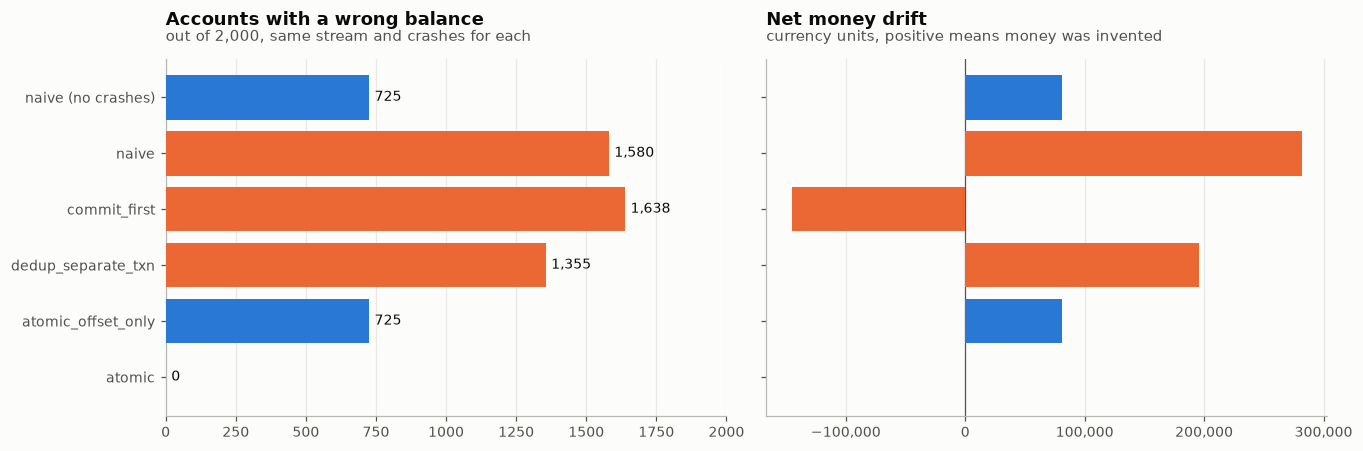

In [12]:
# ============================================================================
# 4.3  Chart accounts wrong and money drift
# ----------------------------------------------------------------------------
# In   : RESULTS
# Out  : two charts
# Note : Same bars, two views. The count says how many accounts are wrong,
#        the drift says by how much.
# ============================================================================
labels = SHOWN[::-1]
wrong = [RESULTS[n]["score"]["accounts_wrong"] for n in labels]
drift = [RESULTS[n]["score"]["net_drift_cents"] / 100 for n in labels]
colours = [AQUA if n == "atomic" else (BLUE if "no crashes" in n or n == "atomic_offset_only" else ORANGE)
           for n in labels]
n_accounts = CFG["stream"]["n_accounts"]

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax[0].barh(labels, wrong, color=colours, zorder=3)
for y, v in enumerate(wrong):
    ax[0].text(v + 20, y, f"{v:,}", va="center", fontsize=9)
style(ax[0], "Accounts with a wrong balance", f"out of {n_accounts:,}, same stream and crashes for each")
ax[0].set_xlim(0, n_accounts)

ax[1].barh(labels, drift, color=colours, zorder=3)
ax[1].axvline(0, color=INK2, linewidth=0.8)
style(ax[1], "Net money drift", "currency units, positive means money was invented")
ax[1].set_yticklabels([])
ax[1].xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

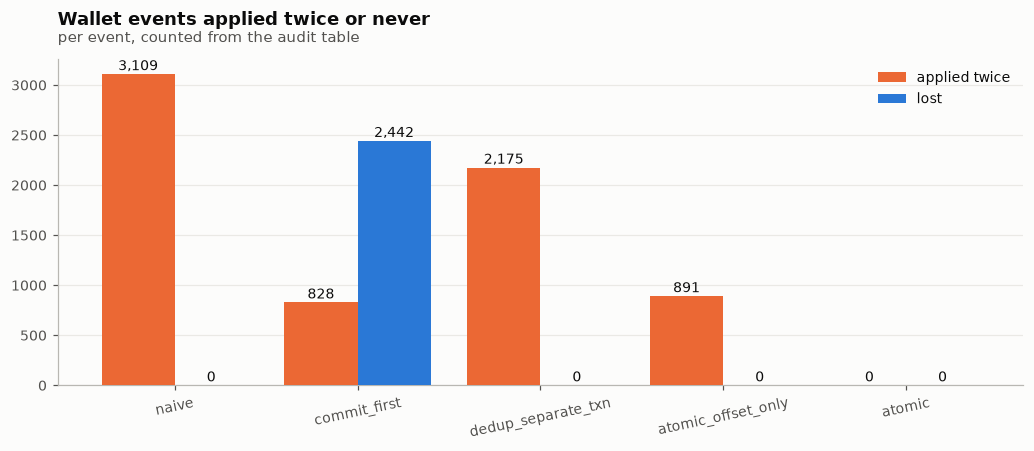

In [13]:
# ============================================================================
# 4.4  Chart lost and doubled events
# ----------------------------------------------------------------------------
# In   : RESULTS
# Out  : one chart
# Note : Commit-first loses events, the others double them, and the two
#        errors have different signs.
# ============================================================================
names = ["naive", "commit_first", "dedup_separate_txn", "atomic_offset_only", "atomic"]
twice = [RESULTS[n]["score"]["applied_twice"] for n in names]
lost = [RESULTS[n]["score"]["events_lost"] for n in names]

fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = range(len(names))
ax.bar([i - 0.2 for i in x], twice, width=0.4, color=ORANGE, label="applied twice", zorder=3)
ax.bar([i + 0.2 for i in x], lost, width=0.4, color=BLUE, label="lost", zorder=3)
for i, (a, b) in enumerate(zip(twice, lost)):
    ax.text(i - 0.2, a + 40, f"{a:,}", ha="center", fontsize=9)
    ax.text(i + 0.2, b + 40, f"{b:,}", ha="center", fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(names, rotation=12)
style(ax, "Wallet events applied twice or never", "per event, counted from the audit table", grid="y")
ax.legend()
plt.tight_layout(); plt.show()

<a id="s5"></a>
## 5. Profile policies

Profile updates carry absolute values, so an upsert can make them idempotent. The
policy decides which update wins.

- `last_arrived_wins` overwrites, so a late update replaces a newer one.
- `time_only_guard` keeps the newest `event_time`, but 40 accounts have two updates in
  the same second, so event time cannot say which is newer.
- `guarded_upsert` compares `(event_time, version)`, and the version breaks the tie.

profile policy    | profiles wrong | accounts with a profile
------------------+----------------+------------------------
last_arrived_wins |            353 |                   1,831
time_only_guard   |             34 |                   1,831
guarded_upsert    |              0 |                   1,831


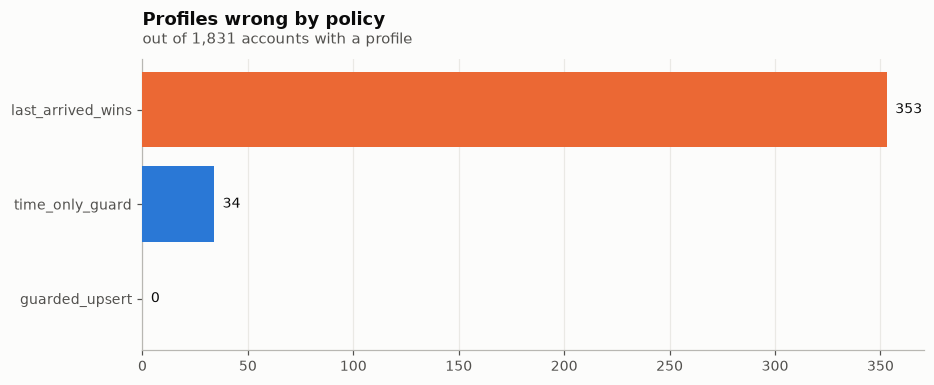

In [14]:
# ============================================================================
# 5.1  Profile policies
# ----------------------------------------------------------------------------
# In   : RESULTS
# Out  : the profile table and one chart
# Note : State events can be made idempotent, but only with a guard that
#        names which update is newest.
# ============================================================================
POLICY_RUNS = ["atomic_last_arrived_wins", "atomic_time_only_guard", "atomic"]
POLICY_NAMES = ["last_arrived_wins", "time_only_guard", "guarded_upsert"]
with_profile = facts["accounts_with_profile"]
print(table(["profile policy", "profiles wrong", "accounts with a profile"],
            [[p, RESULTS[r]["score"]["profiles_wrong"], f"{with_profile:,}"]
             for p, r in zip(POLICY_NAMES, POLICY_RUNS)]))

vals = [RESULTS[r]["score"]["profiles_wrong"] for r in POLICY_RUNS]
fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.barh(POLICY_NAMES[::-1], vals[::-1], color=[AQUA, BLUE, ORANGE], zorder=3)
for y, v in enumerate(vals[::-1]):
    ax.text(v + 4, y, str(v), va="center", fontsize=9)
style(ax, "Profiles wrong by policy", f"out of {with_profile:,} accounts with a profile")
plt.tight_layout(); plt.show()

<a id="s6"></a>
## 6. One account, end to end

The generator picks the smallest account that shows all three faults, and pins one
consumer crash on one of its events. Read the flags column, then the result per strategy.

Account 172 lives in partition 0

offset | event_id | type            | event                        | event_time | attempt | flags                     
-------+----------+-----------------+------------------------------+------------+---------+---------------------------
    72 | w-000233 | wallet_txn      | withdrawal 259.10            | 1760000448 |       0 |                           
    81 | w-000233 | wallet_txn      | withdrawal 259.10            | 1760000448 |       1 | DUPLICATE (producer retry)
   304 | w-000953 | wallet_txn      | withdrawal 220.35            | 1760001920 |       0 | CONSUMER CRASH HERE       
  1677 | w-005109 | wallet_txn      | deposit 323.75               | 1760010197 |       0 |                           
  1703 | w-005177 | wallet_txn      | deposit 355.77               | 1760010332 |       0 |                           
  5196 | w-015962 | wallet_txn      | deposit 148.54               | 1760032012 |       0 |                           
  5867 | w-018


truth balance 493.92   (x0 = lost, x2 = applied twice)

strategy           | balance |   error | events applied wrongly  
-------------------+---------+---------+-------------------------
naive              |   14.47 | -479.45 | w-000233 x2, w-000953 x2
commit_first       |  455.17 |  -38.75 | w-000233 x2, w-000953 x0
dedup_separate_txn |  273.57 | -220.35 | w-000953 x2             
atomic             |  493.92 |    0.00 | -                       


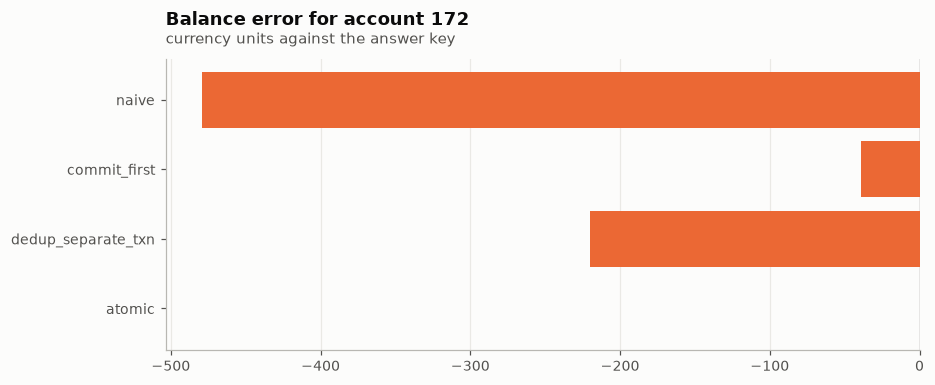

In [15]:
# ============================================================================
# 6.1  One account, end to end
# ----------------------------------------------------------------------------
# In   : log, MANIFEST, RESULTS
# Out  : the trace table and one chart
# Note : The featured account has a producer retry, a consumer crash and an
#        out-of-order profile update.
# ============================================================================
f = MANIFEST["featured"]
account, part = f["account_id"], f["partition"]
crash_set = set(CRASHES)
rows, seen, newest = [], set(), 0
for rec in log.read(part, 0, log.end_offset(part)):
    if rec.key != str(account):
        continue
    v, flags = rec.value, []
    if v["event_id"] in seen:
        flags.append("DUPLICATE (producer retry)")
    if v["type"] == "profile_updated":
        if v["version"] < newest:
            flags.append("OUT OF ORDER")
        newest = max(newest, v["version"])
    seen.add(v["event_id"])
    if (rec.partition, rec.offset) in crash_set:
        flags.append("CONSUMER CRASH HERE")
    what = (f"{v['kind']} {money(v['amount_cents'])}" if v["type"] == "wallet_txn"
            else f"v{v['version']} {v['tier']} limit {money(v['daily_limit_cents'])}")
    rows.append([rec.offset, v["event_id"], v["type"], what, v["event_time"],
                 v["producer_attempt"], ", ".join(flags)])
print(f"Account {account} lives in partition {part}\n")
print(table(["offset", "event_id", "type", "event", "event_time", "attempt", "flags"],
            rows, ["r", "l", "l", "l", "r", "r", "l"]))

truth_balance = ANSWER_KEY["balances"][str(account)]
ids = {r[1] for r in rows}
out, errors = [], {}
for name in ["naive", "commit_first", "dedup_separate_txn", "atomic"]:
    con = RESULTS[name]["sink"].con
    bal = con.execute("SELECT balance_cents FROM balances WHERE account_id = ?", [account]).fetchone()[0]
    applied = dict(con.execute("SELECT event_id, COUNT(*) FROM effect_audit GROUP BY event_id").fetchall())
    odd = {e: applied.get(e, 0) for e in ids if e.startswith("w-") and applied.get(e, 0) != 1}
    errors[name] = (bal - truth_balance) / 100
    out.append([name, money(bal), money(bal - truth_balance),
                ", ".join(f"{e} x{n}" for e, n in sorted(odd.items())) or "-"])
print(f"\ntruth balance {money(truth_balance)}   (x0 = lost, x2 = applied twice)\n")
print(table(["strategy", "balance", "error", "events applied wrongly"], out, ["l", "r", "r", "l"]))

fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.barh(list(errors)[::-1], list(errors.values())[::-1],
        color=[AQUA if v == 0 else ORANGE for v in list(errors.values())[::-1]], zorder=3)
ax.axvline(0, color=INK2, linewidth=0.8)
style(ax, f"Balance error for account {account}", "currency units against the answer key")
plt.tight_layout(); plt.show()

<a id="s7"></a>
## 7. The replay proof

Rewind the consumer to offset zero, consume the whole log into the **same** database,
and hash the tables before and after. A sink that was idempotent gives the same hash.

The proof detects non-idempotence. It cannot repair damage that was already there, so
the table also shows how many accounts were wrong before and after.

In [16]:
# ============================================================================
# 7.1  Replay proof, rewind to offset zero and diff the sink
# ----------------------------------------------------------------------------
# In   : RESULTS, log
# Out  : REPLAYS, the replay table
# Note : Reuses the sinks from the scoreboard. A fresh pass over the whole
#        log goes into the same database and the tables are hashed before
#        and after.
# ============================================================================
CHECKED_TABLES = {"balances": "account_id", "profiles": "account_id",
                  "processed_events": "event_id"}


def _rows(con, table: str) -> list:
    return con.execute(f"SELECT * FROM {table} ORDER BY {CHECKED_TABLES[table]}").fetchall()


def checksum(rows: list) -> str:
    """sha256 over every row in key order, so it does not depend on storage order."""
    h = hashlib.sha256()
    for row in rows:
        h.update(("|".join(str(c) for c in row) + "\n").encode("utf-8"))
    return h.hexdigest()[:16]


def rows_differing(before: list, after: list) -> int:
    a, b = {r[0]: r for r in before}, {r[0]: r for r in after}
    return sum(1 for k in set(a) | set(b) if a.get(k) != b.get(k))


def replay_proof(cfg: dict, log: LogBackend, strategy: str, crashes: list, key: dict,
                 sink: Sink | None = None, label: str | None = None) -> dict:
    """Consume with crashes, rewind to offset zero, consume everything again, diff the sink.

    Pass a sink that has already consumed the log to reuse it instead of consuming again."""
    if sink is None:
        sink, _ = consume(cfg, log, strategy, crashes, label=label)
    con = sink.con
    before = {t: _rows(con, t) for t in CHECKED_TABLES}
    score_before = score_sink(con, key)
    group = group_for(cfg, label or strategy)
    sink.rewind(log, group)
    run_consumer(log, sink, group, cfg["consumer"]["batch_size"], [])
    after = {t: _rows(con, t) for t in CHECKED_TABLES}
    score_after = score_sink(con, key)
    sums_before = {t: checksum(r) for t, r in before.items()}
    sums_after = {t: checksum(r) for t, r in after.items()}
    return {
        "strategy": strategy, "checksum_before": sums_before, "checksum_after": sums_after,
        "balances_differ": rows_differing(before["balances"], after["balances"]),
        "profiles_differ": rows_differing(before["profiles"], after["profiles"]),
        "processed_differ": rows_differing(before["processed_events"], after["processed_events"]),
        "identical": sums_before == sums_after,
        "wrong_before": score_before["accounts_wrong"], "wrong_after": score_after["accounts_wrong"],
        "net_drift_before": score_before["net_drift_cents"],
        "net_drift_after": score_after["net_drift_cents"],
    }


REPLAYS = {}
for name in ["naive", "commit_first", "dedup_separate_txn", "atomic"]:
    REPLAYS[name] = replay_proof(CFG, log, name, CRASHES, ANSWER_KEY, sink=RESULTS[name]["sink"])

rows = []
for name, p in REPLAYS.items():
    rows.append([name, "checksum identical" if p["identical"] else "CHECKSUM DIFFERS",
                 p["balances_differ"], p["profiles_differ"], p["processed_differ"],
                 p["wrong_before"], p["wrong_after"], money(p["net_drift_before"]),
                 money(p["net_drift_after"])])
print(table(["strategy", "verdict", "balance rows differ", "profile rows differ",
             "dedup rows differ", "wrong before", "wrong after", "net drift before",
             "net drift after"], rows, ["l", "l"] + ["r"] * 7))

strategy           | verdict            | balance rows differ | profile rows differ | dedup rows differ | wrong before | wrong after | net drift before | net drift after
-------------------+--------------------+---------------------+---------------------+-------------------+--------------+-------------+------------------+----------------
naive              | CHECKSUM DIFFERS   |                2000 |                   0 |                 0 |         1580 |        2000 |       281,567.11 |    4,403,086.71
commit_first       | CHECKSUM DIFFERS   |                2000 |                 107 |                 0 |         1638 |        2000 |      -145,259.81 |    3,976,259.79
dedup_separate_txn | checksum identical |                   0 |                   0 |                 0 |         1355 |        1355 |       195,421.52 |      195,421.52
atomic             | checksum identical |                   0 |                   0 |                 0 |            0 |           0 |             0.0

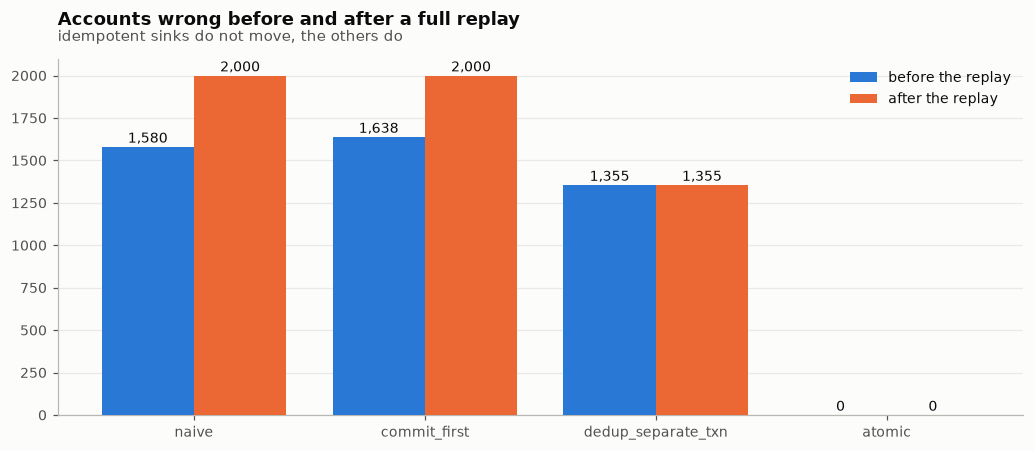

In [17]:
# ============================================================================
# 7.2  Chart the replay result
# ----------------------------------------------------------------------------
# In   : REPLAYS
# Out  : one chart
# Note : Atomic and dedup are idempotent, naive and commit-first are not.
#        Only atomic is also correct.
# ============================================================================
names = list(REPLAYS)
before = [REPLAYS[n]["wrong_before"] for n in names]
after = [REPLAYS[n]["wrong_after"] for n in names]
fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = range(len(names))
ax.bar([i - 0.2 for i in x], before, width=0.4, color=BLUE, label="before the replay", zorder=3)
ax.bar([i + 0.2 for i in x], after, width=0.4, color=ORANGE, label="after the replay", zorder=3)
for i, (a, b) in enumerate(zip(before, after)):
    ax.text(i - 0.2, a + 25, f"{a:,}", ha="center", fontsize=9)
    ax.text(i + 0.2, b + 25, f"{b:,}", ha="center", fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(names)
style(ax, "Accounts wrong before and after a full replay", "idempotent sinks do not move, the others do", grid="y")
ax.legend()
plt.tight_layout(); plt.show()

<a id="s8"></a>
## 8. Batch size against redelivery

The atomic sink commits one transaction per polled batch. A crash rolls the whole
batch back, so a larger batch means more records handled a second time. The result
stays exact at every size. Only the wasted work changes.

batch size | transactions | crashes | records handled | redelivered | accounts wrong | profiles wrong | net drift
-----------+--------------+---------+-----------------+-------------+----------------+----------------+----------
50         |        1,020 |      52 |          52,419 |       1,419 |              0 |              0 |      0.00
100        |          510 |      52 |          53,470 |       2,470 |              0 |              0 |      0.00
500        |          102 |      52 |          62,957 |      11,957 |              0 |              0 |      0.00
5000       |           11 |      52 |         174,952 |     123,952 |              0 |              0 |      0.00


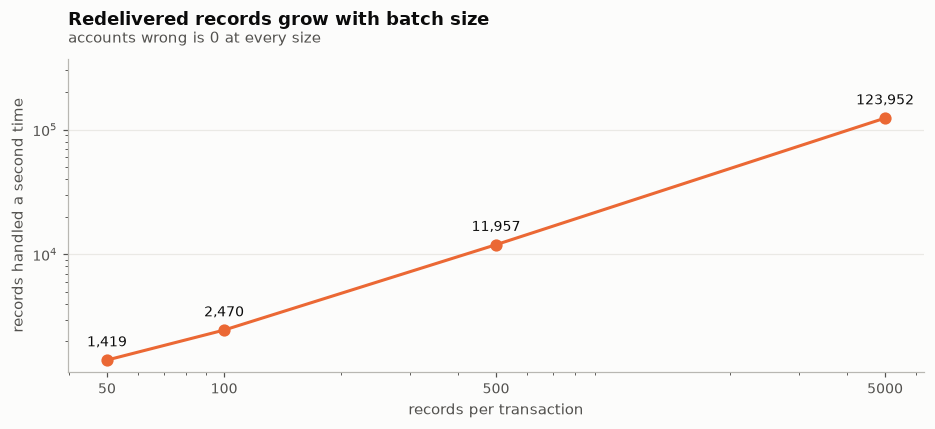

In [18]:
# ============================================================================
# 8.1  Batch size against redelivery
# ----------------------------------------------------------------------------
# In   : RESULTS, log, MANIFEST
# Out  : BATCHES, the batch table, one chart
# Note : Correctness stays perfect at every batch size. Redelivery is what a
#        larger transaction costs.
# ============================================================================
BATCHES = {}
for b in [50, 100, 500, 5000]:
    BATCHES[b] = RESULTS["atomic"] if b == CFG["consumer"]["batch_size"] else \
        run_and_score(CFG, log, "atomic", CRASHES, b)

rows = []
for b, r in BATCHES.items():
    s, st = r["score"], r["stats"]
    rows.append([b, f"{st['polls'] - st['crashes']:,}", st["crashes"], f"{st['records_handled']:,}",
                 f"{st['redelivered']:,}", s["accounts_wrong"], s["profiles_wrong"],
                 money(s["net_drift_cents"])])
print(table(["batch size", "transactions", "crashes", "records handled", "redelivered",
             "accounts wrong", "profiles wrong", "net drift"], rows))

sizes = list(BATCHES)
red = [BATCHES[b]["stats"]["redelivered"] for b in sizes]
fig, ax = plt.subplots(figsize=(8.6, 4))
ax.plot(sizes, red, marker="o", color=ORANGE, zorder=3)
for b, v in zip(sizes, red):
    ax.annotate(f"{v:,}", (b, v), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(sizes); ax.set_xticklabels([str(b) for b in sizes])
ax.set_ylim(top=max(red) * 3)
style(ax, "Redelivered records grow with batch size", "accounts wrong is 0 at every size",
      xlabel="records per transaction", ylabel="records handled a second time", grid="y")
plt.tight_layout(); plt.show()

In [19]:
# ============================================================================
# 9.1  Headline numbers as one JSON line
# ----------------------------------------------------------------------------
# In   : RESULTS, REPLAYS, BATCHES
# Out  : NOTEBOOK_RESULTS
# Note : The repo's test suite compares this line with run.py's artefacts.
# ============================================================================
BOARD = {name: [RESULTS[name]["score"][k] for k in
                ("accounts_wrong", "net_drift_cents", "abs_drift_cents", "events_lost",
                 "applied_twice", "profiles_wrong")] + [RESULTS[name]["stats"]["redelivered"]]
         for name in SHOWN}
NOTEBOOK_RESULTS = {
    "scoreboard": BOARD,
    "profiles": {p: RESULTS[r]["score"]["profiles_wrong"] for p, r in zip(POLICY_NAMES, POLICY_RUNS)},
    "replay": {n: [p["identical"], p["balances_differ"], p["wrong_before"], p["wrong_after"]]
               for n, p in REPLAYS.items()},
    "batches": {str(b): [r["stats"]["polls"] - r["stats"]["crashes"], r["stats"]["records_handled"],
                         r["stats"]["redelivered"], r["score"]["accounts_wrong"]]
                for b, r in BATCHES.items()},
}
print("NOTEBOOK_RESULTS " + json.dumps(NOTEBOOK_RESULTS, sort_keys=True))

NOTEBOOK_RESULTS {"batches": {"100": [510, 53470, 2470, 0], "50": [1020, 52419, 1419, 0], "500": [102, 62957, 11957, 0], "5000": [11, 174952, 123952, 0]}, "profiles": {"guarded_upsert": 0, "last_arrived_wins": 353, "time_only_guard": 34}, "replay": {"atomic": [true, 0, 0, 0], "commit_first": [false, 2000, 1638, 2000], "dedup_separate_txn": [true, 0, 1355, 1355], "naive": [false, 2000, 1580, 2000]}, "scoreboard": {"atomic": [0, 0, 0, 0, 0, 0, 2470], "atomic_offset_only": [725, 8093302, 16218846, 0, 891, 0, 2470], "commit_first": [1638, -14525981, 48191323, 2442, 828, 441, 0], "dedup_separate_txn": [1355, 19542152, 36531892, 0, 2175, 0, 2470], "naive": [1580, 28156711, 47519463, 0, 3109, 353, 2470], "naive (no crashes)": [725, 8093302, 16218846, 0, 891, 353, 0]}}


<a id="s9"></a>
## 9. What this does and does not show

**What the numbers say.**

- Delivery is at-least-once, so the sink has to cope with repeats. Committing the offset
  before the write loses events, and committing after it repeats them.
- A dedup table in a separate transaction removes the producer retries, but a crash
  between the two transactions still repeats the batch. Two transactions can only choose
  which way to be wrong.
- Putting the effect, the event ids and the offset in one transaction gives zero drift.
  The offset alone is not enough, because a producer retry is a second record with a
  new offset.
- Delta events cannot be made idempotent by an upsert. They need effect-level dedup.
  State events can, if the guard compares something that names the newest update.
- The replay proof detects a sink that is not idempotent. It does not repair a sink
  that is already wrong.

**What it does not show.**

- The log is a single process and a single consumer. It has no rebalancing, no
  concurrent consumers and no broker failures.
- Crashes happen at chosen points. A real process can die between any two instructions.
- DuckDB stands in for an OLTP database. Transaction semantics are real, throughput
  numbers are not, and none are claimed.
- Out-of-order updates here are late by a bounded gap. A truly unbounded delay needs a
  watermark policy, which is not modelled.